# Лабораторна робота №3
## Візуалізація даних
### Датасет: Automobile (UCI Machine Learning Repository)

**Джерело:** https://archive.ics.uci.edu/dataset/10/automobile

**Характеристики датасету:**
- Dataset Characteristics: **Multivariate**
- Attribute Characteristics: **Categorical, Integer, Real**
- Number of Instances: 205
- Number of Attributes: 26
- Has Missing Values: **Yes**

Датасет містить характеристики автомобілів: ціна, потужність, витрата палива, тип кузова, виробник тощо.

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Бібліотеки імпортовано успішно!")

Бібліотеки імпортовано успішно!


## 2. Завантаження датасету

Завантажуємо Automobile Dataset з UCI ML Repository. Файл не має заголовків — додаємо їх вручну.

In [2]:
# Назви стовпців з документації UCI
column_names = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_of_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]

# Завантаження з UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
df = pd.read_csv(url, names=column_names, na_values='?')

print(f"Розмір датасету: {df.shape[0]} рядків × {df.shape[1]} стовпців")
print(f"\nТипи даних:")
print(df.dtypes)
df.head()

Розмір датасету: 205 рядків × 26 стовпців

Типи даних:
symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## 3. Data Cleaning

Перевіряємо пропуски, обробляємо їх, конвертуємо типи даних.

In [3]:
# Перевірка пропусків
print("Пропуски по стовпцях:")
print("=" * 40)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_info = pd.DataFrame({'Пропусків': missing, '%': missing_pct})
print(missing_info[missing_info['Пропусків'] > 0])
print(f"\nВсього рядків з пропусками: {df.isnull().any(axis=1).sum()}")

Пропуски по стовпцях:
                   Пропусків      %
normalized_losses         41  20.00
num_of_doors               2   0.98
bore                       4   1.95
stroke                     4   1.95
horsepower                 2   0.98
peak_rpm                   2   0.98
price                      4   1.95

Всього рядків з пропусками: 46


In [4]:
# Заповнення пропусків
# Числові стовпці — медіаною
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col}: заповнено медіаною ({median_val})")

# Категоріальні — модою (найчастіше значення)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  {col}: заповнено модою ('{mode_val}')")

print(f"\nПропусків після очищення: {df.isnull().sum().sum()}")
print(f"Розмір після очищення: {df.shape}")

  normalized_losses: заповнено медіаною (115.0)
  bore: заповнено медіаною (3.31)
  stroke: заповнено медіаною (3.29)
  horsepower: заповнено медіаною (95.0)
  peak_rpm: заповнено медіаною (5200.0)
  price: заповнено медіаною (10295.0)
  num_of_doors: заповнено модою ('four')

Пропусків після очищення: 0
Розмір після очищення: (205, 26)


In [5]:
# Загальна інформація після очищення
df.describe()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,120.600000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329366,3.256098,10.142537,104.165854,5126.097561,25.219512,30.751220,13150.307317
std,1.245307,31.805105,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270858,0.313634,3.972040,39.529733,477.035772,6.542142,6.886443,7879.121326
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 4. Графіки залежності одного integer/real атрибута від іншого

### Графік 1: Scatter plot — Потужність (horsepower) vs Ціна (price)

Досліджуємо залежність ціни автомобіля від його потужності.

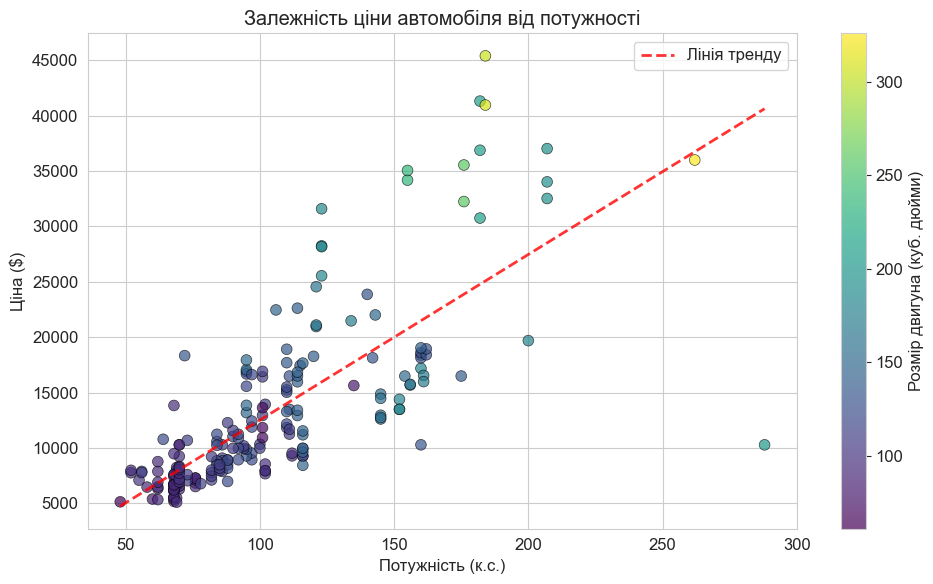

Кореляція horsepower-price: 0.750


In [6]:
# Графік 1: Scatter plot — horsepower vs price
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['horsepower'], df['price'], 
                     c=df['engine_size'], cmap='viridis', 
                     alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label='Розмір двигуна (куб. дюйми)')
ax.set_xlabel('Потужність (к.с.)')
ax.set_ylabel('Ціна ($)')
ax.set_title('Залежність ціни автомобіля від потужності')

# Лінія тренду
z = np.polyfit(df['horsepower'], df['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Лінія тренду')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Кореляція horsepower-price: {df['horsepower'].corr(df['price']):.3f}")

### Графік 2: Line plot — Середня ціна по виробниках

Порівнюємо середню ціну автомобілів різних виробників.

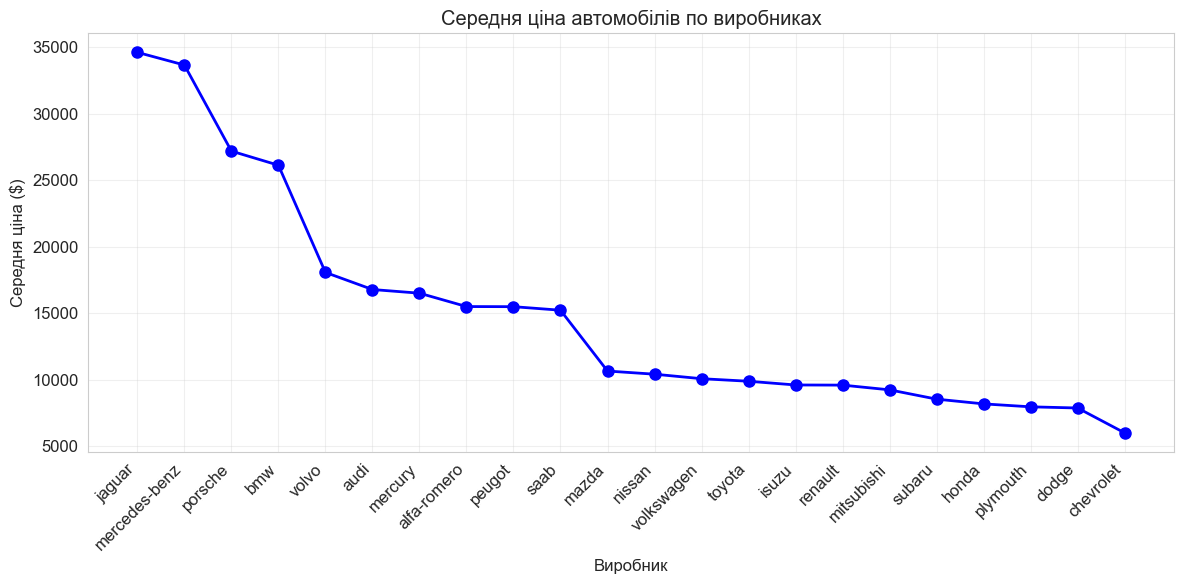

In [7]:
# Графік 2: Line plot — середня ціна по виробниках
make_price = df.groupby('make')['price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(make_price)), make_price.values, 'b-o', markersize=8, linewidth=2)
ax.set_xticks(range(len(make_price)))
ax.set_xticklabels(make_price.index, rotation=45, ha='right')
ax.set_xlabel('Виробник')
ax.set_ylabel('Середня ціна ($)')
ax.set_title('Середня ціна автомобілів по виробниках')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Гістограма з 5 діапазонами

### Графік 3: Гістограма розподілу цін автомобілів

Ділимо ціни на 5 діапазонів та показуємо кількість автомобілів у кожному.

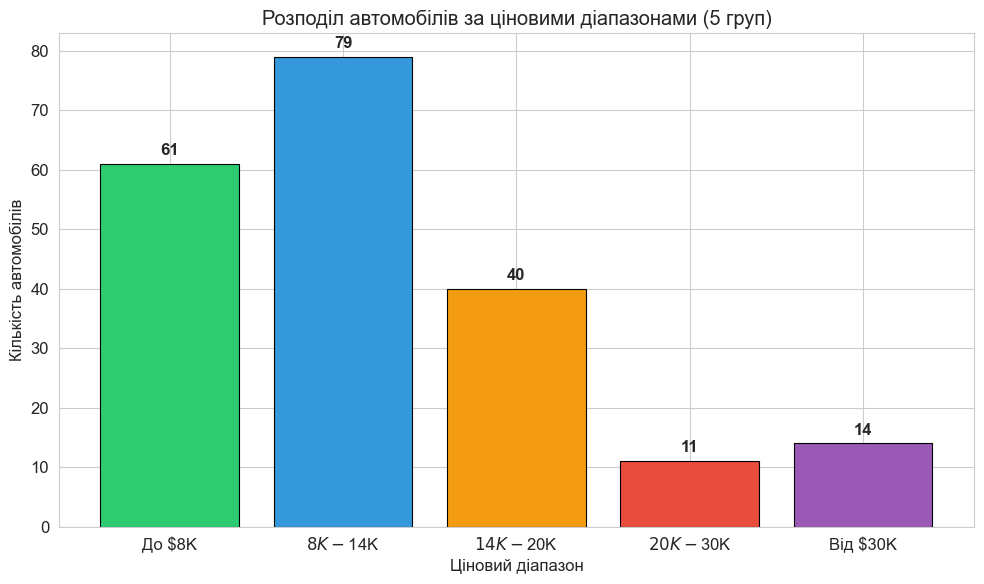

Розподіл за діапазонами:
  До $8K         : 61 авто (29.8%)
  $8K-$14K       : 79 авто (38.5%)
  $14K-$20K      : 40 авто (19.5%)
  $20K-$30K      : 11 авто (5.4%)
  Від $30K       : 14 авто (6.8%)


In [8]:
# Графік 3: Гістограма з 5 діапазонами
fig, ax = plt.subplots(figsize=(10, 6))

# Задаємо 5 діапазонів вручну
bins = [0, 8000, 14000, 20000, 30000, 50000]
labels = ['До $8K', '$8K-$14K', '$14K-$20K', '$20K-$30K', 'Від $30K']

df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)
counts = df['price_range'].value_counts().reindex(labels)

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']
bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.8)

# Додаємо підписи на стовпці
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_xlabel('Ціновий діапазон')
ax.set_ylabel('Кількість автомобілів')
ax.set_title('Розподіл автомобілів за ціновими діапазонами (5 груп)')

plt.tight_layout()
plt.show()

print("Розподіл за діапазонами:")
for label, count in zip(labels, counts.values):
    print(f"  {label:15s}: {count} авто ({count/len(df)*100:.1f}%)")

## 6. Графіки для Multi-Dimensional Data

Побудова графіків за прикладами зі статті [The Art of Effective Visualization of Multi-Dimensional Data](https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57).

### Графік 4: Pair Plot (матриця діаграм розсіювання)

Pair plot дозволяє одночасно побачити залежності між кількома числовими атрибутами, розділеними за категоріальною змінною (тип палива).

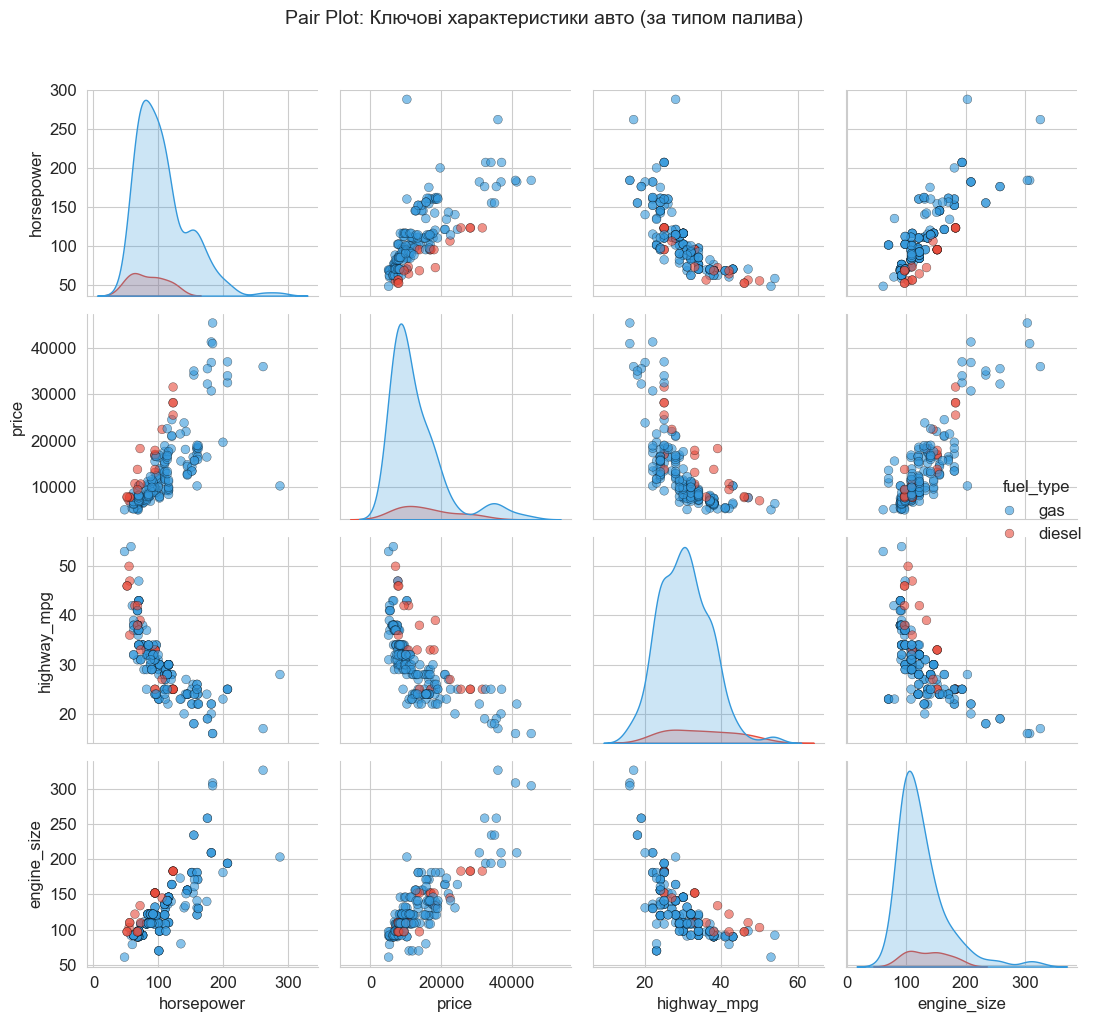

In [9]:
# Графік 4: Pair Plot
selected_cols = ['horsepower', 'price', 'highway_mpg', 'engine_size', 'fuel_type']
pair_df = df[selected_cols].copy()

g = sns.pairplot(pair_df, hue='fuel_type', 
                 palette={'gas': '#3498db', 'diesel': '#e74c3c'},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'black', 'linewidth': 0.3})

g.fig.suptitle('Pair Plot: Ключові характеристики авто (за типом палива)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Графік 5: Violin Plot — Розподіл ціни за типом кузова

Violin plot показує розподіл числового атрибута для кожної категорії — поєднує box plot та KDE.

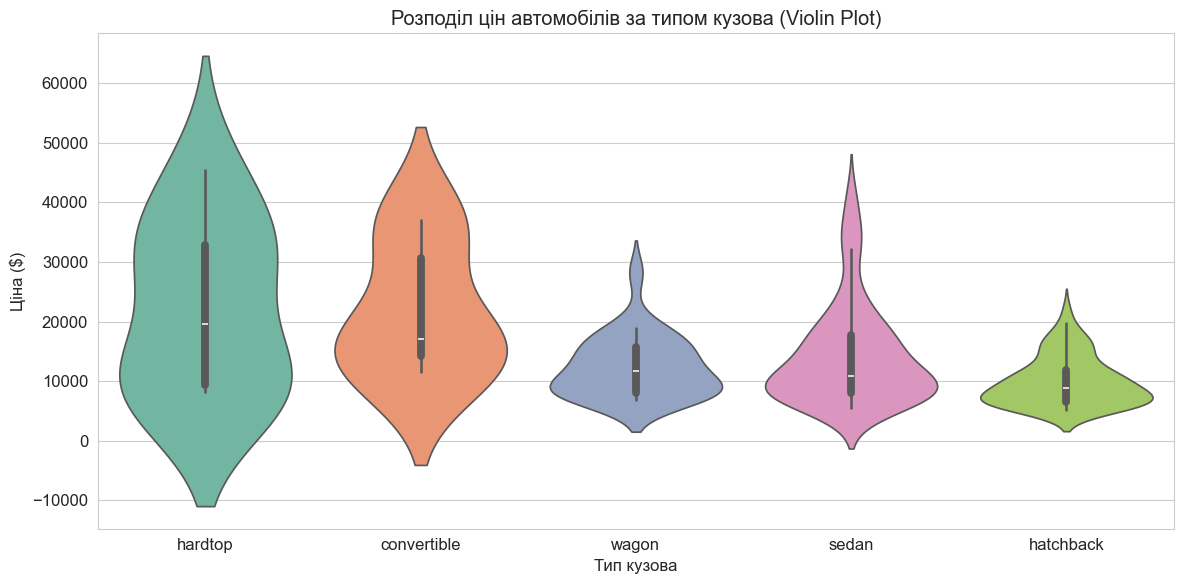

In [10]:
# Графік 5: Violin Plot
fig, ax = plt.subplots(figsize=(12, 6))

order = df.groupby('body_style')['price'].median().sort_values(ascending=False).index
sns.violinplot(data=df, x='body_style', y='price', order=order,
               palette='Set2', inner='box', ax=ax)

ax.set_xlabel('Тип кузова')
ax.set_ylabel('Ціна ($)')
ax.set_title('Розподіл цін автомобілів за типом кузова (Violin Plot)')

plt.tight_layout()
plt.show()

### Графік 6: Heatmap кореляційної матриці

Heatmap ефективно візуалізує кореляцію між усіма числовими атрибутами одночасно — чим темніший колір, тим сильніший зв'язок.

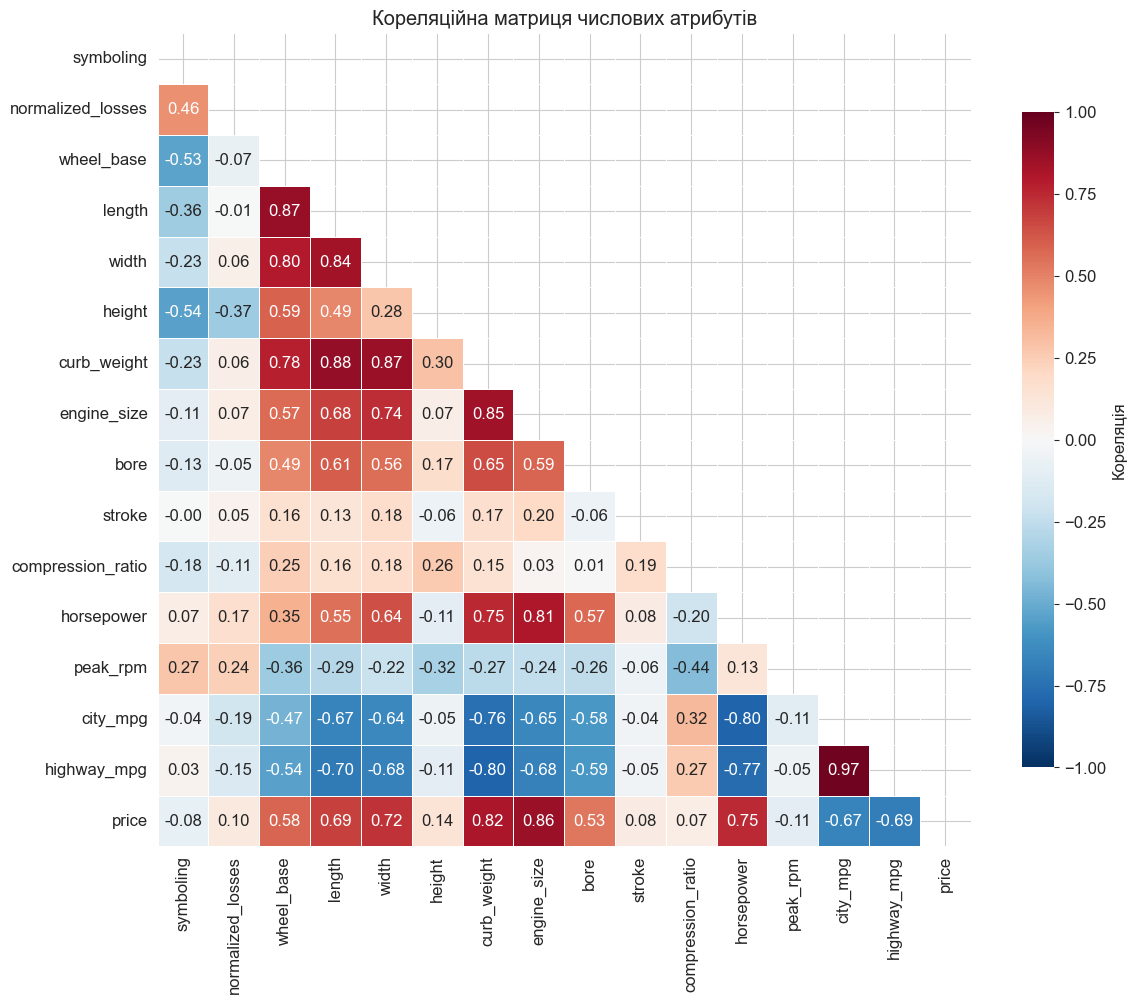


Топ-5 найсильніших кореляцій:
  city_mpg — highway_mpg: 0.971
  length — curb_weight: 0.878
  wheel_base — length: 0.875
  width — curb_weight: 0.867
  engine_size — price: 0.860
  curb_weight — engine_size: 0.851
  length — width: 0.841
  curb_weight — price: 0.820
  engine_size — horsepower: 0.810
  horsepower — city_mpg: -0.802


In [11]:
# Графік 6: Heatmap кореляційної матриці
fig, ax = plt.subplots(figsize=(12, 10))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Кореляція'})

ax.set_title('Кореляційна матриця числових атрибутів')
plt.tight_layout()
plt.show()

# Найсильніші кореляції
print("\nТоп-5 найсильніших кореляцій:")
corr_pairs = corr.unstack().drop_duplicates()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.abs().sort_values(ascending=False).head(10)
for (col1, col2), val in corr_pairs.items():
    real_val = corr.loc[col1, col2]
    print(f"  {col1} — {col2}: {real_val:.3f}")

## 7. Додаткові корисні графіки

### Графік 7: Box Plot — Порівняння потужності за типом приводу

Порівнюємо розподіл потужності для переднього (fwd), заднього (rwd) та повного (4wd) приводу.

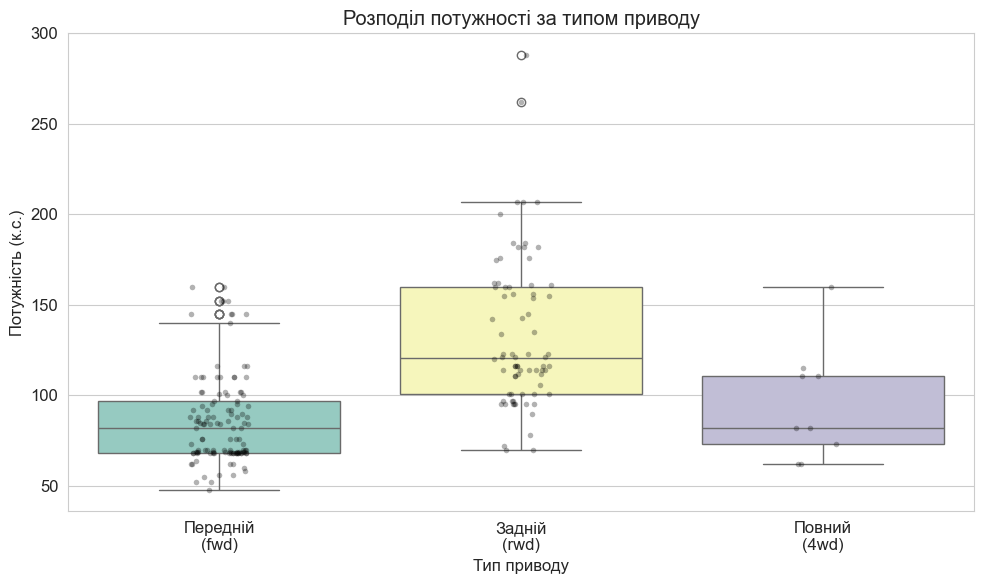

  Передній  : середня=86 к.с., медіана=82 к.с., кількість=120
  Задній    : середня=134 к.с., медіана=120 к.с., кількість=76
  Повний    : середня=95 к.с., медіана=82 к.с., кількість=9


In [12]:
# Графік 7: Box Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='drive_wheels', y='horsepower', 
            palette='Set3', ax=ax, order=['fwd', 'rwd', '4wd'])

# Додаємо точки поверх
sns.stripplot(data=df, x='drive_wheels', y='horsepower',
              color='black', alpha=0.3, size=4, ax=ax, order=['fwd', 'rwd', '4wd'])

ax.set_xlabel('Тип приводу')
ax.set_ylabel('Потужність (к.с.)')
ax.set_title('Розподіл потужності за типом приводу')

# Підписи
labels_map = {'fwd': 'Передній', 'rwd': 'Задній', '4wd': 'Повний'}
ax.set_xticklabels([f"{labels_map[t.get_text()]}\n({t.get_text()})" for t in ax.get_xticklabels()])

plt.tight_layout()
plt.show()

for dw in ['fwd', 'rwd', '4wd']:
    subset = df[df['drive_wheels'] == dw]['horsepower']
    print(f"  {labels_map[dw]:10s}: середня={subset.mean():.0f} к.с., медіана={subset.median():.0f} к.с., кількість={len(subset)}")

### Графік 8: Bubble Chart — Витрата палива vs Ціна vs Потужність

Bubble chart дозволяє відобразити 3 виміри одночасно: x, y та розмір точки. Четвертий вимір — колір (тип палива).

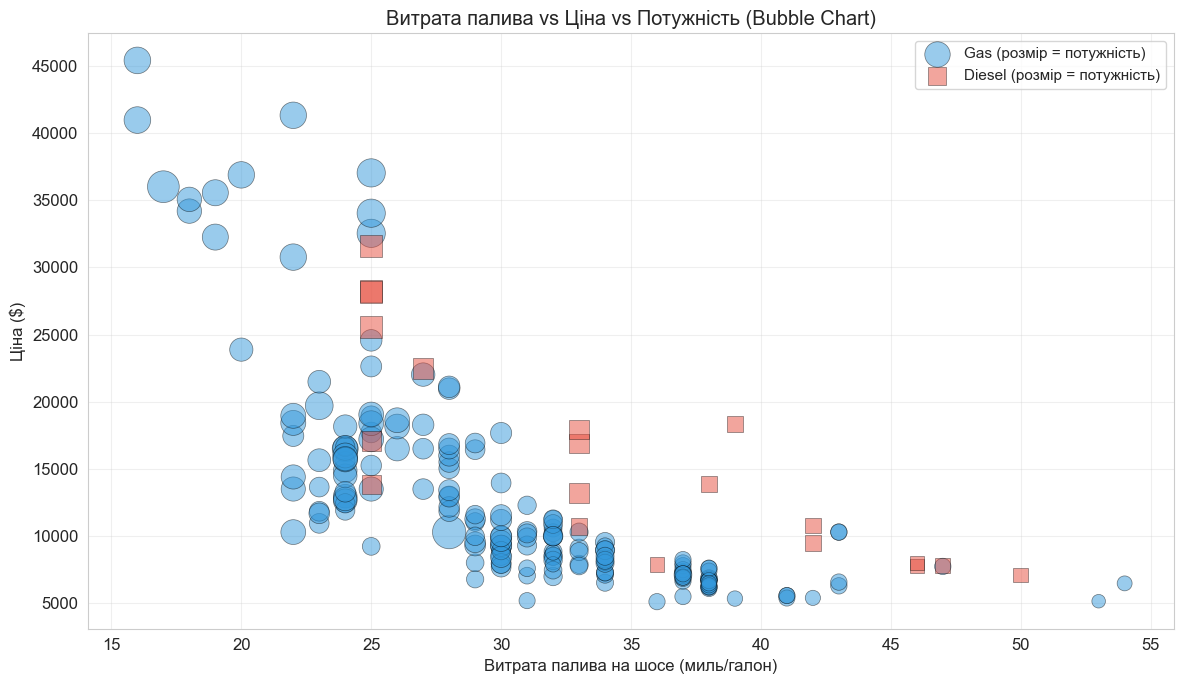

In [13]:
# Графік 8: Bubble Chart
fig, ax = plt.subplots(figsize=(12, 7))

for fuel, color, marker in [('gas', '#3498db', 'o'), ('diesel', '#e74c3c', 's')]:
    subset = df[df['fuel_type'] == fuel]
    ax.scatter(subset['highway_mpg'], subset['price'],
               s=subset['horsepower'] * 2,  # розмір = потужність
               c=color, alpha=0.5, edgecolors='black', linewidth=0.5,
               label=f'{fuel.capitalize()} (розмір = потужність)', marker=marker)

ax.set_xlabel('Витрата палива на шосе (миль/галон)')
ax.set_ylabel('Ціна ($)')
ax.set_title('Витрата палива vs Ціна vs Потужність (Bubble Chart)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Підсумок

**Побудовано 8 графіків:**

| # | Тип | Що показує |
|---|-----|-----------|
| 1 | Scatter plot | Залежність ціни від потужності (з лінією тренду) |
| 2 | Line plot | Середня ціна по виробниках |
| 3 | Гістограма | Розподіл цін по 5 діапазонах |
| 4 | Pair plot | Матриця залежностей ключових атрибутів |
| 5 | Violin plot | Розподіл цін за типом кузова |
| 6 | Heatmap | Кореляційна матриця числових атрибутів |
| 7 | Box plot | Порівняння потужності за типом приводу |
| 8 | Bubble chart | 4D візуалізація: витрата, ціна, потужність, паливо |

**Висновки:**
- Ціна автомобіля сильно корелює з потужністю, розміром двигуна та масою
- Дизельні авто мають кращу економічність, але зазвичай дорожчі
- Задньопривідні авто в середньому потужніші (спорткари, преміум-клас)
- Більшість авто в датасеті знаходяться у ціновому діапазоні до $14,000